In [55]:
import matplotlib.pyplot as plt
import numpy as np
import petab
import pandas as pd
import seaborn as sns

from dmm.config_options import Conf
from dmm.feature_selection import contextualize_measurements
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from util import load_petab_base_files

DATA = "dream_cytof"
MODEL = "EGFR_MAPK"

# updated load_petab_base_files takes in Conf object
conf = Conf(model=MODEL, data=DATA)
files = load_petab_base_files(conf)

mat = contextualize_measurements(
    measurement_table=files["measurement_table"],
    observable_table=files["observable_table"],
    contextualization="cytof_dynamic"
)

/var/folders/lt/n6z6ygk55q583z32lhqt4x8mg_mvwv/T/ipykernel_76449/1438913951.py:20: DeprecationWarning: Accessing `petab.SIMULATION_CONDITION_ID` is deprecated and will be removed in the next major release. Please use `petab.v1.SIMULATION_CONDITION_ID` instead.
  mat = contextualize_measurements(
/var/folders/lt/n6z6ygk55q583z32lhqt4x8mg_mvwv/T/ipykernel_76449/1438913951.py:20: DeprecationWarning: Accessing `petab.OBSERVABLE_ID` is deprecated and will be removed in the next major release. Please use `petab.v1.OBSERVABLE_ID` instead.
  mat = contextualize_measurements(
/var/folders/lt/n6z6ygk55q583z32lhqt4x8mg_mvwv/T/ipykernel_76449/1438913951.py:20: DeprecationWarning: Accessing `petab.TIME` is deprecated and will be removed in the next major release. Please use `petab.v1.TIME` instead.
  mat = contextualize_measurements(
/var/folders/lt/n6z6ygk55q583z32lhqt4x8mg_mvwv/T/ipykernel_76449/1438913951.py:20: DeprecationWarning: Accessing `petab.PREEQUILIBRATION_CONDITION_ID` is deprecated an

In [56]:
mat.shape

(40, 91)

In [57]:
mat_nonans = mat.dropna(how="any", axis=1)

In [58]:
mat_nonans - mat_nonans.mean(axis=0)  # mat.mean(axis=0) is the average (for a specific perturbation, observable, timepoint) across ALL cell-lines

observableId                pERK_Y204_obs                                \
simulationConditionId                 EGF                                 
time                                 0.0       5.5       7.0       9.0    
preequilibrationConditionId                                               
c184A1                          -0.350333 -0.139768 -0.091485  0.117242   
cBT20                            0.888055  0.274045  0.811122  0.686338   
cBT474                           0.180832 -0.363466 -0.484502 -0.264094   
cBT549                          -0.126480  0.154046  0.430810  0.241190   
cCAL148                         -0.967816 -0.125071 -0.277747 -0.037866   
cCAL51                          -0.295564  0.336702  0.255550  0.375655   
cCAL851                          0.383980  0.115759 -0.037380  0.279551   
cDU4475                          0.391376 -0.409692 -0.932466 -0.464465   
cEFM192A                        -0.299475 -0.717495 -0.398785 -0.342235   
cEVSAT                          -1.167585 -1.097662 -1.080528 -1.143885   
cHBL100                          0.031652  0.312812  0.602988  0.204772   
cHCC1187                         0.353285  0.444390  0.361401  0.529193   
cHCC1395                        -0.713976  0.175473  0.088636  0.085990   
cHCC1419                         0.846630  0.352690 -0.199374 -0.012714   
cHCC1500                        -0.729072 -1.348921 -1.832651 -1.587924   
cHCC1569                        -0.155495  0.249850  0.290531  0.190401   
cHCC1937                         0.806410  1.022830  0.990561  0.976126   
cHCC1954                         0.380689  0.625255  0.357545  0.499211   
cHCC2185                         0.264941  0.057043  0.058412  0.198401   
cHCC3153                         0.779773  0.492134  0.451961  0.278396   
cHCC38                           1.545861  1.133463  1.239549  1.161324   
cHCC70                           0.358748  0.074290  0.615556  0.194718   
cHDQP1                           0.676853  0.413338  0.553127  0.542678   
cJIMT1                           0.263423  0.206853 -0.166407  0.118042   
cMCF10A                         -0.860729 -0.193262  0.093092  0.085956   
cMCF7                           -1.257439 -1.207101 -0.870506 -1.076505   
cMDAMB134VI                      0.013421 -0.565333 -0.602300 -0.622317   
cMDAMB157                       -0.185780  0.605563  0.630156  0.527430   
cMDAMB175VII                     0.232988  0.269077  0.275438  0.389400   
cMDAMB361                       -0.823495  0.134625  0.190731  0.133916   
cMDAMB415                        0.330805 -1.012795 -1.110151 -1.451683   
cMDAMB453                       -0.010732  0.081545  0.194456  0.044001   
cMFM223                          0.506078 -0.106567 -0.485143 -0.587819   
cMPE600                          0.191319 -0.416963 -0.353983 -0.394836   
cMX1                            -0.211608  0.159583  0.108524  0.229994   
cOCUBM                          -0.286691  0.633263  0.422965  0.218075   
cT47D                           -1.061321  0.056559  0.161265  0.201291   
cUACC812                        -0.047028 -0.506876 -0.449688 -0.385449   
cUACC893                        -0.350177  0.101855  0.299086  0.042241   
cZR7530                          0.473679 -0.272084 -0.110374 -0.179740   

observableId                                                                   \
simulationConditionId                                                   iEGFR   
time                             17.0      23.0      30.0      60.0      0.0    
preequilibrationConditionId                                                     
c184A1                       0.008381  0.342579 -0.026420 -0.345099 -0.268924   
cBT20                        1.230158  0.629194  1.268782  1.037400  0.687079   
cBT474                      -0.056797 -0.293933 -0.057858 -0.031347 -0.565539   
cBT549                       0.404063  0.091276  0.458280  0.348286  0.469415   
cCAL148                      0.052978  0.092413  0.

In [59]:
res = (mat_nonans - mat_nonans.mean(axis=0)).apply(lambda x: np.power(x, 2)).mean(axis=1)
res

preequilibrationConditionId
c184A1          0.097351
cBT20           0.688124
cBT474          0.090133
cBT549          0.159124
cCAL148         0.147106
cCAL51          0.129771
cCAL851         0.059733
cDU4475         0.470586
cEFM192A        0.212074
cEVSAT          0.547837
cHBL100         0.051129
cHCC1187        0.240270
cHCC1395        0.112628
cHCC1419        0.155670
cHCC1500        0.664514
cHCC1569        0.122809
cHCC1937        0.479509
cHCC1954        0.244542
cHCC2185        0.505282
cHCC3153        0.065887
cHCC38          0.484470
cHCC70          0.122960
cHDQP1          0.312700
cJIMT1          0.228992
cMCF10A         0.134313
cMCF7           0.731856
cMDAMB134VI     0.247603
cMDAMB157       0.303896
cMDAMB175VII    0.343427
cMDAMB361       0.361376
cMDAMB415       0.346464
cMDAMB453       0.166603
cMFM223         0.311536
cMPE600         0.058216
cMX1            0.086041
cOCUBM          0.131522
cT47D           0.144300
cUACC812        0.207618
cUACC893        0.2200

In [60]:
res.sort_values(ascending=False).head(10)
# top 5 cell-lines for deviation from the mean: cMCF7, cBT20, cHCC1500, cEVSAT, cHCC2185 -> 5 CV splits
# following 5: cHCC38, cHCC1937, cDU4475, cMDAMB361, cMDAMB415

preequilibrationConditionId
cMCF7        0.731856
cBT20        0.688124
cHCC1500     0.664514
cEVSAT       0.547837
cHCC2185     0.505282
cHCC38       0.484470
cHCC1937     0.479509
cDU4475      0.470586
cMDAMB361    0.361376
cMDAMB415    0.346464
dtype: float64

In [61]:
res.sort_values(ascending=False).index.tolist()

['cMCF7',
 'cBT20',
 'cHCC1500',
 'cEVSAT',
 'cHCC2185',
 'cHCC38',
 'cHCC1937',
 'cDU4475',
 'cMDAMB361',
 'cMDAMB415',
 'cMDAMB175VII',
 'cHDQP1',
 'cMFM223',
 'cMDAMB157',
 'cZR7530',
 'cMDAMB134VI',
 'cHCC1954',
 'cHCC1187',
 'cJIMT1',
 'cUACC893',
 'cEFM192A',
 'cUACC812',
 'cMDAMB453',
 'cBT549',
 'cHCC1419',
 'cCAL148',
 'cT47D',
 'cMCF10A',
 'cOCUBM',
 'cCAL51',
 'cHCC70',
 'cHCC1569',
 'cHCC1395',
 'c184A1',
 'cBT474',
 'cMX1',
 'cHCC3153',
 'cCAL851',
 'cMPE600',
 'cHBL100']

<Axes: ylabel='Frequency'>

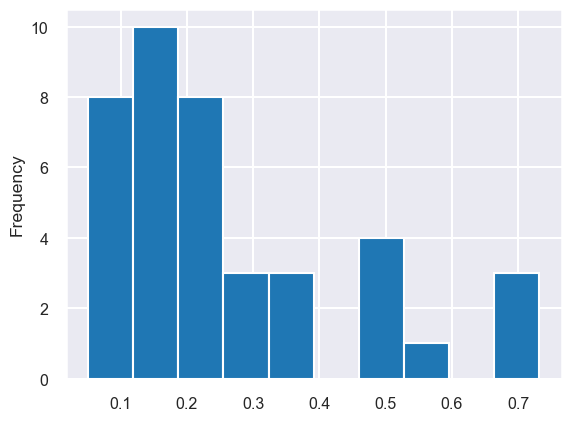

In [62]:
res.plot.hist()

In [63]:
list(res[res.values > 2].index)  # only cell-line, 'cHCC1599', has already been dropped as outlier

[]

In [64]:
mat.drop(list(res[res.values > 2].index), axis=0, inplace=True)

In [65]:
X = mat.values
# impute missing values prior to PCA
X_imputed = KNNImputer().fit_transform(X)

from sklearn.decomposition import PCA

pca = PCA(n_components=10)
Xt = pca.fit_transform(X_imputed)

In [66]:
Xt.shape  # it appears 3 other cell-lines have been dropped (no transcriptomic data), previous notebook had 43 remaining cell-lines

(40, 10)

In [67]:
X.shape

(40, 91)

In [68]:
Xt[:, 0]

array([-0.44374613, -6.02699537, -0.05391359, -0.77672053, -0.06182148,
       -1.55583792, -0.63504072, -2.6391943 ,  2.39358313,  3.76020112,
        1.36722099, -3.1925736 ,  0.84432543,  1.20497214,  4.58154818,
       -0.73525474, -3.75741776, -3.9903031 , -4.96356227, -0.73784324,
       -4.02218618,  1.0764702 , -3.45855709, -2.64747353,  0.29885104,
        6.8123345 ,  5.15347988, -0.52106335, -1.00527863,  2.29744238,
        2.99557686,  2.23167781,  0.13423507,  1.47292442,  1.05014364,
        0.45133552, -0.94717882,  2.02298814,  2.64146607, -0.61881415])

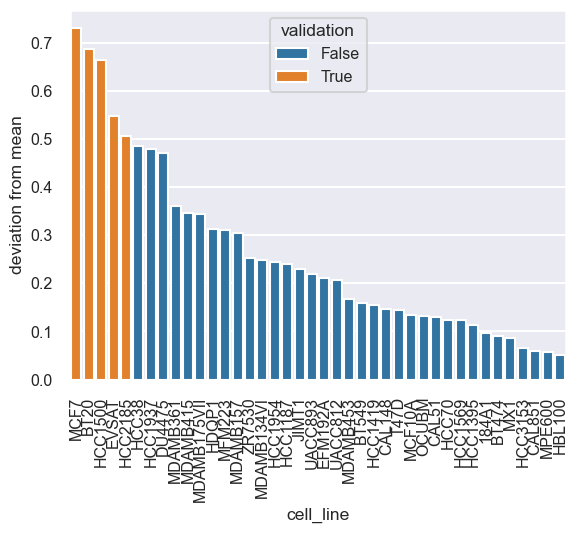

In [69]:
plt.rcParams.update({'font.size': 8})
res.name = "deviation from mean"
res.index.name = "cell_line"
res_df = res.reset_index()
res_df[res.index.name] = res_df[res.index.name].apply(lambda x: x[1:])
threshold = res.sort_values(ascending=False).head(5).min()
res_df["validation"] = res_df[res.name] >= threshold
res_df.sort_values(res.name, ascending=False, inplace=True)
sns.barplot(res_df, x=res.index.name, y=res.name, hue="validation", dodge=False)
# rotate x-axis labels
plt.xticks(rotation=90)
# decrease font size
res_df.set_index(res.index.name, inplace=True)

In [70]:
res_df.index

Index(['MCF7', 'BT20', 'HCC1500', 'EVSAT', 'HCC2185', 'HCC38', 'HCC1937',
       'DU4475', 'MDAMB361', 'MDAMB415', 'MDAMB175VII', 'HDQP1', 'MFM223',
       'MDAMB157', 'ZR7530', 'MDAMB134VI', 'HCC1954', 'HCC1187', 'JIMT1',
       'UACC893', 'EFM192A', 'UACC812', 'MDAMB453', 'BT549', 'HCC1419',
       'CAL148', 'T47D', 'MCF10A', 'OCUBM', 'CAL51', 'HCC70', 'HCC1569',
       'HCC1395', '184A1', 'BT474', 'MX1', 'HCC3153', 'CAL851', 'MPE600',
       'HBL100'],
      dtype='object', name='cell_line')

In [71]:
N_COMPS = 2
df = pd.DataFrame(
    index=[c[1:] for c in mat.index],
    data=Xt[:, :N_COMPS],
    columns=["PC1", "PC2"],
)
df.index.name = res.index.name
# select 5 strongest outliers as validation set
df["validation"] = res_df["validation"]
df

,PC1,PC2,validation
cell_line,,,
184A1,-0.443746,-0.358431,False
BT20,-6.026995,-1.964092,True
BT474,-0.053914,-1.103320,False
BT549,-0.776721,1.782567,False
CAL148,-0.061821,1.193988,False
CAL51,-1.555838,0.858877,False
CAL851,-0.635041,0.495130,False
DU4475,-2.639194,0.998366,False
EFM192A,2.393583,-1.444571,False


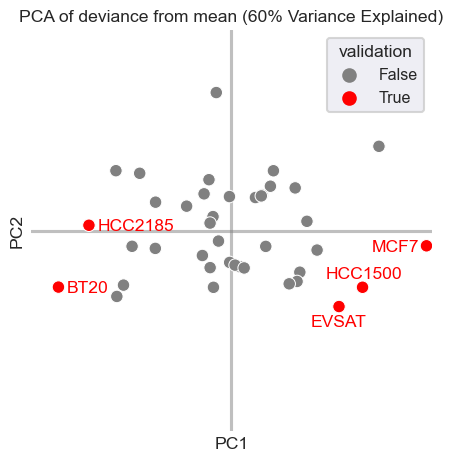

In [91]:
sns.set_context("talk", font_scale=0.7)
g = sns.scatterplot(
    data=df, 
    x="PC1", 
    y="PC2", 
    hue="validation", 
    palette=["gray", "red"],
    
)
# add cell-line labels for 5 validation cell-lines
for _, r in df.iterrows():
    if r.validation:
        ox = 0.3
        oy = -0.2
        if r.name == "EVSAT":
            ox = -1.0
            oy = -0.7
        if r.name == "HCC1500":
            ox = -1.3
            oy = 0.3
        if r.name == "MCF7":
            ox = -1.9
        plt.annotate(r.name, (r.PC1+ox, r.PC2+oy), color="red")

# export with transparent background and high dpi, remove grid
# no box around plot
# add dashed line at 0 for both axes with low zorder to ensure it is behind the data points
# make plot square
# make axis limits equal and remove axis labels
g.set(xlim=(-7, 7), ylim=(-7, 7), aspect=1.0, xticks=[], yticks=[])
# 
plt.axhline(0, color='gray', zorder=0, alpha=0.5)
plt.axvline(0, color='gray', zorder=0, alpha=0.5)
plt.box(False)
plt.grid(False)
VE = sum(pca.explained_variance_ratio_[:2])
plt.title(f"PCA of deviance from mean ({VE*100:.0f}% Variance Explained)")
plt.tight_layout()
plt.savefig("cytof_pca.png", transparent=True, dpi=300)


In [73]:
pca.explained_variance_ratio_

array([0.43984136, 0.15714793, 0.11781873, 0.06269396, 0.04710861,
       0.03739395, 0.0216317 , 0.01844937, 0.01463355, 0.0132125 ])

In [74]:
pca.components_.shape

(10, 91)

In [75]:
pc_mat = pd.DataFrame(
    index=[f"PC{i}" for i in np.arange(N_COMPS)],
    data=pca.components_[:N_COMPS, :],
    columns=mat.columns,
)
pc_mat

observableId          pERBB2_Y1248_obs                                \
simulationConditionId              EGF                                 
time                              0.0       5.5       7.0       9.0    
PC0                          -0.064153 -0.118026 -0.102590 -0.125694   
PC1                          -0.124780 -0.103289 -0.109479 -0.111753   

observableId                                                                \
simulationConditionId                                                        
time                       13.0          14.0      17.0      23.0     30.0   
PC0                   -0.122682  6.852174e-17 -0.134121 -0.092856 -0.12884   
PC1                   -0.136398 -1.250808e-17 -0.111657 -0.113663 -0.15266   

observableId                     ... pMEK_S222_obs                     \
simulationConditionId            ...          iMEK                      
time                       40.0  ...          0.0      7.0       9.0    
PC0                   -0.134334  ...     -0.041103 -0.06080 -0.065412   
PC1                   -0.140881  ...     -0.104264 -0.08785 -0.092529   

observableId                                                                  
simulationConditionId                                                         
time                       13.0 14.0 15.0 16.0      17.0      40.0      60.0  
PC0                   -0.085674  0.0  0.0  0.0 -0.074241 -0.075020 -0.081981  
PC1                   -0.098304 -0.0 -0.0 -0.0 -0.091874 -0.095948 -0.116373  

[2 rows x 91 columns]

In [76]:
pc_mat_long = pd.melt(pc_mat.reset_index(), id_vars="index")
pc_mat_long

KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['index']"

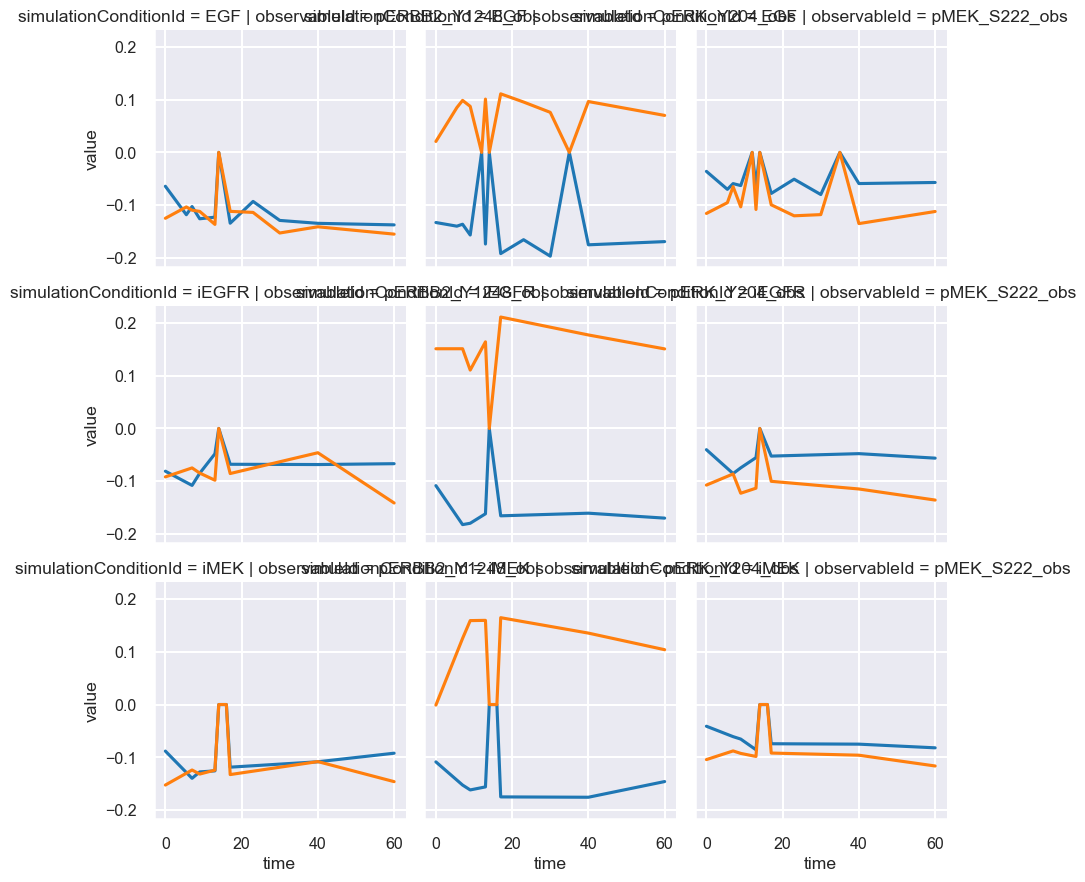

In [23]:
g = sns.FacetGrid(
    data=pc_mat_long, col=petab.OBSERVABLE_ID, row="simulationConditionId", hue="index"
)
g.map_dataframe(sns.lineplot, x="time", y="value")
# Previous notebook showed 5 perturbation, but we have now removed iPI3K and iPKC -> 3 left (EGF, iEGFR, iMEK)